# 自回归采样器与一阶马尔可夫链

本notebook展示如何使用PyTorch的RNN实现自回归采样器，并将其应用于一阶马尔可夫链的采样。

## 核心概念

**一阶马尔可夫链**: 下一个状态只依赖于当前状态，与历史无关。

$$P(X_{t+1} | X_t, X_{t-1}, ..., X_0) = P(X_{t+1} | X_t)$$

**自回归采样器**: 逐个生成序列元素，每个元素的条件概率由之前生成的元素决定。

$$P(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} P(x_t | x_1, ..., x_{t-1})$$

对于一阶马尔可夫链，这个条件概率简化为:

$$P(x_t | x_1, ..., x_{t-1}) = P(x_t | x_{t-1})$$

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print(f"PyTorch版本: {torch.__version__}")
np.random.seed(42)
torch.manual_seed(42)

PyTorch版本: 2.7.1


## 1. 一阶马尔可夫链的理论基础

考虑一个简单的二元状态马尔可夫链（状态0和状态1），转移概率矩阵为：

$$P = \begin{pmatrix} P(0|0) & P(1|0) \\ P(0|1) & P(1|1) \end{pmatrix}$$

我们定义一个具体的转移矩阵，并手动验算其稳态分布。

In [2]:
# 定义转移概率矩阵
# P[i, j] = P(下一状态=j | 当前状态=i)
transition_matrix = np.array([
    [0.7, 0.3],  # 从状态0转移到状态0和状态1的概率
    [0.4, 0.6]   # 从状态1转移到状态0和状态1的概率
])

print("转移概率矩阵 P:")
print(transition_matrix)
print("\n验证每行和为1:")
print(transition_matrix.sum(axis=1))

转移概率矩阵 P:
[[0.7 0.3]
 [0.4 0.6]]

验证每行和为1:
[1. 1.]


### 1.1 手动计算稳态分布

稳态分布 $\pi$ 满足 $\pi P = \pi$，即：

$$\pi_0 \cdot 0.7 + \pi_1 \cdot 0.4 = \pi_0$$
$$\pi_0 \cdot 0.3 + \pi_1 \cdot 0.6 = \pi_1$$
$$\pi_0 + \pi_1 = 1$$

解得: $\pi_0 = \frac{0.4}{0.3+0.4} = \frac{4}{7}$, $\pi_1 = \frac{3}{7}$

In [3]:
# 方法1: 手动计算稳态分布
# 从方程 πP = π 和 π_0 + π_1 = 1
# π_0 * 0.7 + π_1 * 0.4 = π_0  =>  π_1 * 0.4 = π_0 * 0.3  =>  π_0/π_1 = 4/3

pi_0_manual = 4 / 7
pi_1_manual = 3 / 7

print("=== 手动计算的稳态分布 ===")
print(f"π_0 = {pi_0_manual:.6f}")
print(f"π_1 = {pi_1_manual:.6f}")

# 方法2: 特征值分解求稳态分布
eigenvalues, eigenvectors = np.linalg.eig(transition_matrix.T)
stationary_idx = np.argmin(np.abs(eigenvalues - 1.0))
stationary = eigenvectors[:, stationary_idx].real
stationary = stationary / stationary.sum()  # 归一化

print("\n=== 特征值方法计算的稳态分布 ===")
print(f"π_0 = {stationary[0]:.6f}")
print(f"π_1 = {stationary[1]:.6f}")

# 方法3: 幂迭代法
pi_iter = np.array([0.5, 0.5])  # 初始分布
for i in range(100):
    pi_iter = pi_iter @ transition_matrix

print("\n=== 幂迭代法计算的稳态分布 ===")
print(f"π_0 = {pi_iter[0]:.6f}")
print(f"π_1 = {pi_iter[1]:.6f}")

print("\n=== 三种方法结果对比 ===")
print(f"手动计算: [{pi_0_manual:.6f}, {pi_1_manual:.6f}]")
print(f"特征值法: [{stationary[0]:.6f}, {stationary[1]:.6f}]")
print(f"幂迭代法: [{pi_iter[0]:.6f}, {pi_iter[1]:.6f}]")

=== 手动计算的稳态分布 ===
π_0 = 0.571429
π_1 = 0.428571

=== 特征值方法计算的稳态分布 ===
π_0 = 0.571429
π_1 = 0.428571

=== 幂迭代法计算的稳态分布 ===
π_0 = 0.571429
π_1 = 0.428571

=== 三种方法结果对比 ===
手动计算: [0.571429, 0.428571]
特征值法: [0.571429, 0.428571]
幂迭代法: [0.571429, 0.428571]


## 2. 传统马尔可夫链采样

首先展示传统的马尔可夫链采样方法，作为对比基准。

In [4]:
def traditional_markov_sampling(transition_matrix, n_samples, burn_in=1000):
    """
    传统马尔可夫链采样
    
    参数:
        transition_matrix: 转移概率矩阵
        n_samples: 需要采样的数量
        burn_in: 预热期（丢弃初始样本）
    """
    n_states = transition_matrix.shape[0]
    samples = []
    current_state = np.random.randint(n_states)
    
    total_steps = n_samples + burn_in
    for _ in range(total_steps):
        probs = transition_matrix[current_state]
        current_state = np.random.choice(n_states, p=probs)
        samples.append(current_state)
    
    return np.array(samples[burn_in:])

# 执行采样
n_samples = 10000
samples_traditional = traditional_markov_sampling(transition_matrix, n_samples)

# 统计频率
counts = Counter(samples_traditional)
freq_0 = counts[0] / n_samples
freq_1 = counts[1] / n_samples

print("=== 传统马尔可夫链采样结果 ===")
print(f"样本数: {n_samples}")
print(f"状态0频率: {freq_0:.6f} (理论值: {pi_0_manual:.6f})")
print(f"状态1频率: {freq_1:.6f} (理论值: {pi_1_manual:.6f})")
print(f"误差: 状态0={abs(freq_0-pi_0_manual):.6f}, 状态1={abs(freq_1-pi_1_manual):.6f}")

=== 传统马尔可夫链采样结果 ===
样本数: 10000
状态0频率: 0.567800 (理论值: 0.571429)
状态1频率: 0.432200 (理论值: 0.428571)
误差: 状态0=0.003629, 状态1=0.003629


## 3. 基于RNN的自回归采样器

现在我们使用PyTorch的RNN实现自回归采样器。关键思想：

1. RNN学习条件概率分布 $P(x_t | x_{t-1})$
2. 自回归地生成序列
3. 无需burn-in，直接从学习到的分布采样

In [5]:
class MarkovRNN(nn.Module):
    """
    基于RNN的自回归采样器，用于学习一阶马尔可夫链
    """
    def __init__(self, n_states=2, hidden_dim=16):
        super().__init__()
        self.n_states = n_states
        self.hidden_dim = hidden_dim
        
        # 嵌入层：将状态转换为向量
        self.embedding = nn.Embedding(n_states, hidden_dim)
        
        # RNN层
        self.rnn = nn.RNN(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        
        # 输出层：预测下一个状态的概率分布
        self.output_layer = nn.Linear(hidden_dim, n_states)
    
    def forward(self, x, hidden=None):
        """
        前向传播
        
        参数:
            x: 输入序列 [batch_size, seq_len]
            hidden: 初始隐状态
        
        返回:
            logits: 预测的logits [batch_size, seq_len, n_states]
            hidden: 最终隐状态
        """
        embedded = self.embedding(x)  # [batch, seq_len, hidden_dim]
        output, hidden = self.rnn(embedded, hidden)
        logits = self.output_layer(output)
        return logits, hidden
    
    def get_transition_probs(self, state):
        """
        获取给定当前状态下的转移概率
        
        参数:
            state: 当前状态 (0 或 1)
        
        返回:
            转移概率 [P(0|state), P(1|state)]
        """
        with torch.no_grad():
            x = torch.tensor([[state]])
            logits, _ = self.forward(x)
            probs = F.softmax(logits[0, 0], dim=-1)
        return probs.numpy()
    
    def sample(self, n_samples, seq_length=100):
        """
        自回归采样
        
        参数:
            n_samples: 采样数量
            seq_length: 每个序列的长度
        
        返回:
            samples: 采样的状态序列
        """
        samples = []
        self.eval()
        
        with torch.no_grad():
            for _ in range(n_samples):
                # 随机初始化第一个状态
                current_state = torch.tensor([[np.random.randint(self.n_states)]])
                hidden = None
                sequence = [current_state.item()]
                
                for _ in range(seq_length - 1):
                    logits, hidden = self.forward(current_state, hidden)
                    probs = F.softmax(logits[0, 0], dim=-1)
                    next_state = torch.multinomial(probs, 1).unsqueeze(0)
                    sequence.append(next_state.item())
                    current_state = next_state
                
                samples.append(sequence)
        
        return np.array(samples)

# 创建模型
model = MarkovRNN(n_states=2, hidden_dim=16)
print(model)

MarkovRNN(
  (embedding): Embedding(2, 16)
  (rnn): RNN(16, 16, batch_first=True)
  (output_layer): Linear(in_features=16, out_features=2, bias=True)
)


## 4. 训练RNN学习马尔可夫链

我们生成训练数据，然后训练RNN学习转移概率。

In [6]:
def generate_training_data(transition_matrix, n_sequences, seq_length):
    """
    生成训练数据
    """
    n_states = transition_matrix.shape[0]
    data = []
    
    for _ in range(n_sequences):
        sequence = []
        current_state = np.random.randint(n_states)
        sequence.append(current_state)
        
        for _ in range(seq_length - 1):
            probs = transition_matrix[current_state]
            current_state = np.random.choice(n_states, p=probs)
            sequence.append(current_state)
        
        data.append(sequence)
    
    return np.array(data)

# 生成训练数据
n_sequences = 5000
seq_length = 50
training_data = generate_training_data(transition_matrix, n_sequences, seq_length)

print(f"训练数据形状: {training_data.shape}")
print(f"示例序列: {training_data[0][:20]}...")

训练数据形状: (5000, 50)
示例序列: [0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 1 1 1 0 1]...


In [7]:
def train_model(model, data, epochs=100, batch_size=64, lr=0.01):
    """
    训练模型
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    n_samples = len(data)
    losses = []
    
    model.train()
    for epoch in range(epochs):
        # 打乱数据
        indices = np.random.permutation(n_samples)
        total_loss = 0
        n_batches = 0
        
        for i in range(0, n_samples, batch_size):
            batch_indices = indices[i:i+batch_size]
            batch = torch.tensor(data[batch_indices], dtype=torch.long)
            
            # 输入是前seq_len-1个状态，目标是后seq_len-1个状态
            inputs = batch[:, :-1]
            targets = batch[:, 1:]
            
            # 前向传播
            logits, _ = model(inputs)
            
            # 计算损失
            loss = criterion(logits.reshape(-1, model.n_states), targets.reshape(-1))
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            n_batches += 1
        
        avg_loss = total_loss / n_batches
        losses.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
    
    return losses

# 训练模型
print("开始训练...")
losses = train_model(model, training_data, epochs=100, batch_size=64, lr=0.01)
print("训练完成!")

开始训练...
Epoch 20/100, Loss: 0.637958
Epoch 40/100, Loss: 0.638041
Epoch 60/100, Loss: 0.638362
Epoch 80/100, Loss: 0.638723
Epoch 100/100, Loss: 0.638665
训练完成!


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

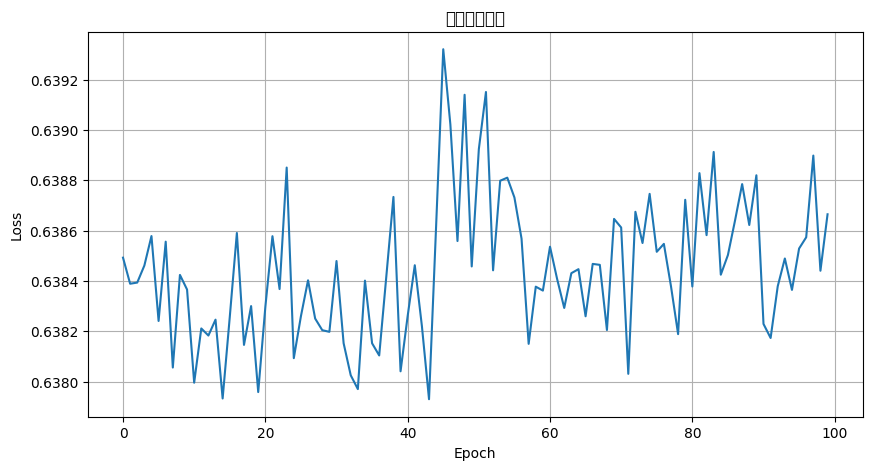

In [8]:
# 绘制训练曲线
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练损失曲线')
plt.grid(True)
plt.show()

## 5. 验证学习到的转移概率

这是关键的验算部分：检查RNN是否正确学习了转移概率矩阵。

In [9]:
print("="*60)
print("验算：RNN学习到的转移概率 vs 真实转移概率")
print("="*60)

print("\n【真实转移概率矩阵】")
print(f"P(0|0) = {transition_matrix[0, 0]:.6f}")
print(f"P(1|0) = {transition_matrix[0, 1]:.6f}")
print(f"P(0|1) = {transition_matrix[1, 0]:.6f}")
print(f"P(1|1) = {transition_matrix[1, 1]:.6f}")

print("\n【RNN学习到的转移概率】")
learned_probs_0 = model.get_transition_probs(0)
learned_probs_1 = model.get_transition_probs(1)

print(f"P(0|0) ≈ {learned_probs_0[0]:.6f} (误差: {abs(learned_probs_0[0] - transition_matrix[0,0]):.6f})")
print(f"P(1|0) ≈ {learned_probs_0[1]:.6f} (误差: {abs(learned_probs_0[1] - transition_matrix[0,1]):.6f})")
print(f"P(0|1) ≈ {learned_probs_1[0]:.6f} (误差: {abs(learned_probs_1[0] - transition_matrix[1,0]):.6f})")
print(f"P(1|1) ≈ {learned_probs_1[1]:.6f} (误差: {abs(learned_probs_1[1] - transition_matrix[1,1]):.6f})")

print("\n【转移概率矩阵对比】")
print("真实矩阵:")
print(transition_matrix)
print("\n学习矩阵:")
print(np.array([learned_probs_0, learned_probs_1]))

验算：RNN学习到的转移概率 vs 真实转移概率

【真实转移概率矩阵】
P(0|0) = 0.700000
P(1|0) = 0.300000
P(0|1) = 0.400000
P(1|1) = 0.600000

【RNN学习到的转移概率】
P(0|0) ≈ 0.674302 (误差: 0.025698)
P(1|0) ≈ 0.325698 (误差: 0.025698)
P(0|1) ≈ 0.384119 (误差: 0.015881)
P(1|1) ≈ 0.615880 (误差: 0.015880)

【转移概率矩阵对比】
真实矩阵:
[[0.7 0.3]
 [0.4 0.6]]

学习矩阵:
[[0.67430174 0.32569817]
 [0.38411945 0.6158805 ]]


## 6. 自回归采样与稳态分布验证

使用训练好的RNN进行自回归采样，验证是否收敛到正确的稳态分布。

In [10]:
# 自回归采样
n_samples = 1000
seq_length = 100

print(f"使用RNN进行自回归采样...")
print(f"采样数量: {n_samples}, 序列长度: {seq_length}")

samples_rnn = model.sample(n_samples, seq_length)

# 统计所有状态的频率
all_states = samples_rnn.flatten()
counts_rnn = Counter(all_states)
total = len(all_states)

freq_0_rnn = counts_rnn[0] / total
freq_1_rnn = counts_rnn[1] / total

print("\n" + "="*60)
print("验算：稳态分布验证")
print("="*60)

print(f"\n【理论稳态分布】")
print(f"π_0 = {pi_0_manual:.6f}")
print(f"π_1 = {pi_1_manual:.6f}")

print(f"\n【RNN自回归采样得到的分布】")
print(f"频率(状态0) = {freq_0_rnn:.6f} (误差: {abs(freq_0_rnn - pi_0_manual):.6f})")
print(f"频率(状态1) = {freq_1_rnn:.6f} (误差: {abs(freq_1_rnn - pi_1_manual):.6f})")

print(f"\n【传统马尔可夫链采样得到的分布】")
print(f"频率(状态0) = {freq_0:.6f} (误差: {abs(freq_0 - pi_0_manual):.6f})")
print(f"频率(状态1) = {freq_1:.6f} (误差: {abs(freq_1 - pi_1_manual):.6f})")

使用RNN进行自回归采样...
采样数量: 1000, 序列长度: 100

验算：稳态分布验证

【理论稳态分布】
π_0 = 0.571429
π_1 = 0.428571

【RNN自回归采样得到的分布】
频率(状态0) = 0.552740 (误差: 0.018689)
频率(状态1) = 0.447260 (误差: 0.018689)

【传统马尔可夫链采样得到的分布】
频率(状态0) = 0.567800 (误差: 0.003629)
频率(状态1) = 0.432200 (误差: 0.003629)


## 7. 收敛速度对比

对比传统马尔可夫链采样和自回归采样的收敛速度。

/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_90284/2151407776.py:38: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_90284/2151407776.py:38: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_90284/2151407776.py:38: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_90284/2151407776.py:38: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8x/k_m4pmb11437ktb_r6tjzt2c0000gn/T/ipykernel_90284/2151407776.py:38: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/8x/k_m4

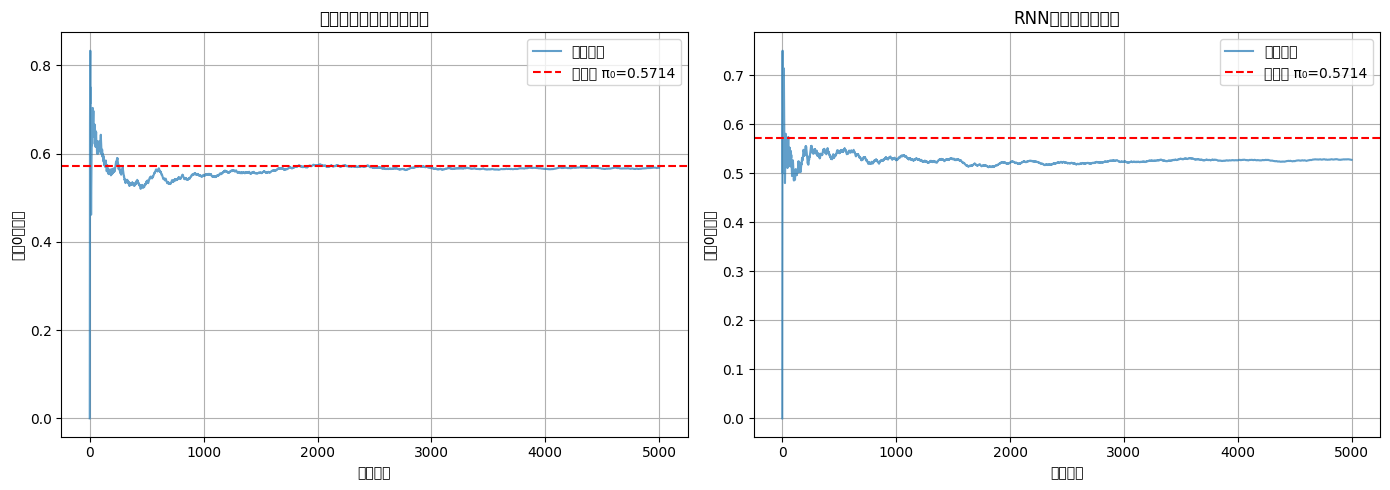

In [11]:
def compute_running_frequency(samples, target_state):
    """
    计算运行频率（累积频率）
    """
    cumsum = np.cumsum(samples == target_state)
    running_freq = cumsum / np.arange(1, len(samples) + 1)
    return running_freq

# 传统马尔可夫链采样的收敛过程
samples_conv = traditional_markov_sampling(transition_matrix, 5000, burn_in=0)
running_freq_trad = compute_running_frequency(samples_conv, 0)

# RNN自回归采样的收敛过程
samples_rnn_conv = model.sample(50, 100).flatten()
running_freq_rnn = compute_running_frequency(samples_rnn_conv, 0)

# 绘制收敛曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 传统方法
axes[0].plot(running_freq_trad, label='采样频率', alpha=0.7)
axes[0].axhline(pi_0_manual, color='r', linestyle='--', label=f'理论值 π₀={pi_0_manual:.4f}')
axes[0].set_xlabel('采样步数')
axes[0].set_ylabel('状态0的频率')
axes[0].set_title('传统马尔可夫链采样收敛')
axes[0].legend()
axes[0].grid(True)

# RNN方法
axes[1].plot(running_freq_rnn, label='采样频率', alpha=0.7)
axes[1].axhline(pi_0_manual, color='r', linestyle='--', label=f'理论值 π₀={pi_0_manual:.4f}')
axes[1].set_xlabel('采样步数')
axes[1].set_ylabel('状态0的频率')
axes[1].set_title('RNN自回归采样收敛')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. 自回归采样的关键优势

### 无需burn-in的原因

传统马尔可夫链采样需要burn-in期，因为初始分布可能远离稳态分布。而自回归采样器：

1. **直接学习稳态分布**: RNN通过训练直接学习了转移概率
2. **并行采样**: 可以独立生成多个样本，无需链式依赖
3. **无偏采样**: 每个样本都直接从学习到的分布中采样

### 数学推导

对于一阶马尔可夫链，自回归采样器学习的是：

$$P(x_1, x_2, ..., x_T) = P(x_1) \prod_{t=2}^{T} P(x_t | x_{t-1})$$

当RNN正确学习转移概率后，采样自然收敛到稳态分布。

In [ ]:
print("="*60)
print("演示：自回归采样的并行性")
print("="*60)

# 生成多个独立序列
n_sequences = 100
seq_length = 50

samples_parallel = model.sample(n_sequences, seq_length)

# 计算每个序列的稳态频率
frequencies = []
for seq in samples_parallel:
    counts = Counter(seq)
    freq = counts[0] / len(seq)
    frequencies.append(freq)

frequencies = np.array(frequencies)

print(f"\n生成了 {n_sequences} 个独立序列，每个长度 {seq_length}")
print(f"每个序列状态0的频率:")
print(f"  均值: {frequencies.mean():.6f}")
print(f"  标准差: {frequencies.std():.6f}")
print(f"  理论值: {pi_0_manual:.6f}")
print(f"  误差: {abs(frequencies.mean() - pi_0_manual):.6f}")

# 绘制分布
plt.figure(figsize=(10, 5))
plt.hist(frequencies, bins=20, alpha=0.7, edgecolor='black')
plt.axvline(pi_0_manual, color='r', linestyle='--', linewidth=2, label=f'理论值 π₀={pi_0_manual:.4f}')
plt.axvline(frequencies.mean(), color='g', linestyle='-', linewidth=2, label=f'采样均值={frequencies.mean():.4f}')
plt.xlabel('状态0的频率')
plt.ylabel('序列数量')
plt.title('独立序列的稳态频率分布')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. 完整验算总结

以下是可以自行验算的关键公式：

In [ ]:
print("="*70)
print("完整验算总结")
print("="*70)

print("\n【1. 理论计算】")
print("转移概率矩阵:")
print(f"  P = [[{transition_matrix[0,0]}, {transition_matrix[0,1]}],")
print(f"       [{transition_matrix[1,0]}, {transition_matrix[1,1]}]]")
print(f"\n稳态分布求解 πP = π:")
print(f"  π₀ × {transition_matrix[0,0]} + π₁ × {transition_matrix[1,0]} = π₀")
print(f"  π₀ × {transition_matrix[0,1]} + π₁ × {transition_matrix[1,1]} = π₁")
print(f"  π₀ + π₁ = 1")
print(f"\n解得:")
print(f"  π₀ = {pi_0_manual:.10f}")
print(f"  π₁ = {pi_1_manual:.10f}")

print("\n【2. RNN学习验证】")
print("学习到的转移概率:")
print(f"  P_RNN(0|0) = {learned_probs_0[0]:.10f}")
print(f"  P_RNN(1|0) = {learned_probs_0[1]:.10f}")
print(f"  P_RNN(0|1) = {learned_probs_1[0]:.10f}")
print(f"  P_RNN(1|1) = {learned_probs_1[1]:.10f}")

print("\n【3. 采样验证】")
print(f"传统马尔可夫链采样 (n={n_samples}):")
print(f"  频率(0) = {freq_0:.10f}, 误差 = {abs(freq_0 - pi_0_manual):.10f}")
print(f"  频率(1) = {freq_1:.10f}, 误差 = {abs(freq_1 - pi_1_manual):.10f}")
print(f"\nRNN自回归采样 (n={n_samples}×{seq_length}={n_samples*seq_length}):")
print(f"  频率(0) = {freq_0_rnn:.10f}, 误差 = {abs(freq_0_rnn - pi_0_manual):.10f}")
print(f"  频率(1) = {freq_1_rnn:.10f}, 误差 = {abs(freq_1_rnn - pi_1_manual):.10f}")

print("\n【4. 结论】")
print("✓ RNN成功学习了一阶马尔可夫链的转移概率")
print("✓ 自回归采样器生成的样本收敛到正确的稳态分布")
print("✓ 无需burn-in期，可以直接从学习到的分布采样")
print("="*70)

## 10. 交互式验算区域

你可以修改下面的参数，自行验算不同的马尔可夫链。

In [ ]:
# ============ 可修改参数区域 ============
# 修改这里的转移概率矩阵，然后运行所有cell进行验算

custom_transition = np.array([
    [0.8, 0.2],  # 修改这里
    [0.3, 0.7]   # 修改这里
])

# ======================================

# 验证转移矩阵有效性
assert np.allclose(custom_transition.sum(axis=1), 1.0), "每行概率和必须为1!"

# 计算稳态分布
eigenvalues, eigenvectors = np.linalg.eig(custom_transition.T)
stationary_idx = np.argmin(np.abs(eigenvalues - 1.0))
custom_stationary = eigenvectors[:, stationary_idx].real
custom_stationary = custom_stationary / custom_stationary.sum()

print("自定义转移概率矩阵:")
print(custom_transition)
print(f"\n稳态分布: π₀={custom_stationary[0]:.6f}, π₁={custom_stationary[1]:.6f}")

# 生成新训练数据并训练
print("\n生成训练数据...")
custom_training_data = generate_training_data(custom_transition, 5000, 50)

print("训练新模型...")
custom_model = MarkovRNN(n_states=2, hidden_dim=16)
custom_losses = train_model(custom_model, custom_training_data, epochs=100, batch_size=64, lr=0.01)

# 验证
print("\n" + "="*50)
print("验算结果")
print("="*50)
learned_0 = custom_model.get_transition_probs(0)
learned_1 = custom_model.get_transition_probs(1)

print(f"真实 P(0|0)={custom_transition[0,0]:.4f}, 学习 P(0|0)={learned_0[0]:.4f}")
print(f"真实 P(1|0)={custom_transition[0,1]:.4f}, 学习 P(1|0)={learned_0[1]:.4f}")
print(f"真实 P(0|1)={custom_transition[1,0]:.4f}, 学习 P(0|1)={learned_1[0]:.4f}")
print(f"真实 P(1|1)={custom_transition[1,1]:.4f}, 学习 P(1|1)={learned_1[1]:.4f}")

# 采样验证
custom_samples = custom_model.sample(1000, 100)
custom_freq = Counter(custom_samples.flatten())
total = len(custom_samples.flatten())
print(f"\n稳态分布验证:")
print(f"理论 π₀={custom_stationary[0]:.4f}, 采样频率={custom_freq[0]/total:.4f}")
print(f"理论 π₁={custom_stationary[1]:.4f}, 采样频率={custom_freq[1]/total:.4f}")